# 第8章 数学工具 · 课堂代码

> 本 notebook 与课件《Python金融数据分析 · 第8章 数学工具》配套。
> 内容改编自《Python金融大数据分析（第2版）》第11章。

**本章四大工具**：逼近（回归/插值）、优化、积分、符号计算。
示例函数贯穿全章：$f(x) = \sin(x) + 0.5x$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

def f(x):
    return np.sin(x) + 0.5 * x

## 1. 函数逼近：回归

`np.polyfit(x, y, deg)` 找一条 deg 次多项式使误差平方和最小；
`np.polyval(reg, x)` 用拟合系数求值。

In [2]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 50)

for deg in (1, 5, 7):
    reg = np.polyfit(x, f(x), deg)
    mse = np.mean((f(x) - np.polyval(reg, x)) ** 2)
    print(f"{deg}次多项式  MSE = {mse:.6f}")

1次多项式  MSE = 0.420648
5次多项式  MSE = 0.053883
7次多项式  MSE = 0.001777


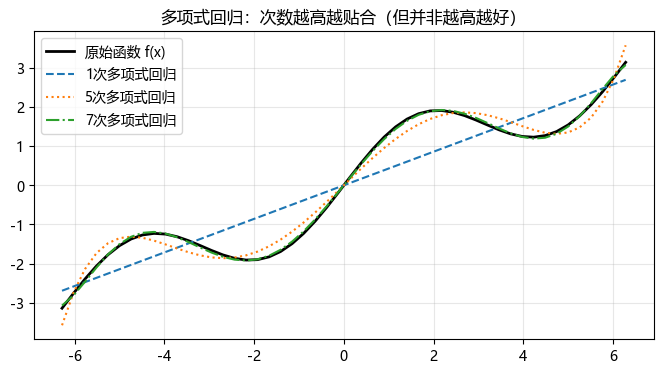

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, f(x), "k", linewidth=2, label="原始函数 f(x)")
for deg, ls in [(1, "--"), (5, ":"), (7, "-.")]:
    reg = np.polyfit(x, f(x), deg)
    ax.plot(x, np.polyval(reg, x), ls, linewidth=1.5,
            label=f"{deg}次多项式回归")
ax.set_title("多项式回归：次数越高越贴合（但并非越高越好）")
ax.legend()
ax.grid(alpha=0.3)

**回归的优点**：抗噪声（平均掉噪声）、不要求数据排序。

**过拟合警告**：次数过高会穿过每个噪声点、在点间剧烈震荡。

## 2. 函数逼近：插值

`splrep`（构造）+ `splev`（求值），要求数据有序且无噪声。

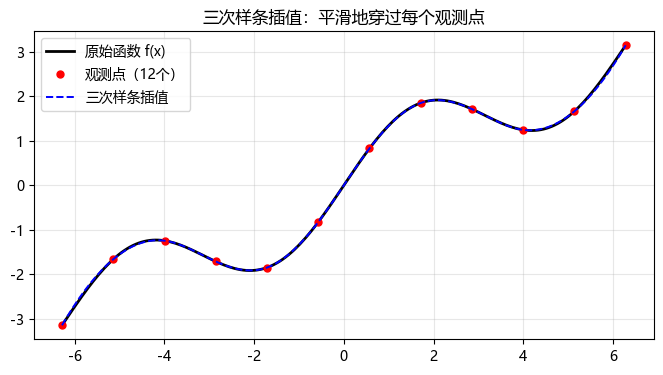

In [4]:
import scipy.interpolate as spi

xa = np.linspace(-2 * np.pi, 2 * np.pi, 12)  # 12个观测点
ya = f(xa)
ipo = spi.splrep(xa, ya, k=3)    # 构造三次样条
xs = np.linspace(-2 * np.pi, 2 * np.pi, 200)
iy = spi.splev(xs, ipo)          # 在更密的网格上求值

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, f(xs), "k", linewidth=2, label="原始函数 f(x)")
ax.plot(xa, ya, "ro", markersize=5, label="观测点（12个）")
ax.plot(xs, iy, "b--", linewidth=1.4, label="三次样条插值")
ax.set_title("三次样条插值：平滑地穿过每个观测点")
ax.legend()
ax.grid(alpha=0.3)

**金融应用：收益率曲线插值**——市场只有整期限利率，定价需要 7.5 年的利率怎么办？插值。

In [5]:
maturity = [1, 3, 5, 10]              # 已知期限（年）
rate     = [1.5, 2.1, 2.6, 3.2]       # 对应利率（%）
ipo2 = spi.splrep(maturity, rate, k=3)
round(float(spi.splev(7.5, ipo2)), 3)  # 7.5年期利率 ≈ 3.04%

3.035

## 3. 优化：寻找最优解

两步走：`brute`（全局网格粗搜）→ `fmin`（局部精修）。
局部算法像"闭眼下山"：从哪出发就掉进哪个坑。

In [6]:
import scipy.optimize as sco

def fm(p):
    x, y = p
    return np.sin(x) + 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2

# 1. 全局：网格上逐点尝试（暴力但可靠）
opt1 = sco.brute(fm, ((-10, 10.1, 0.1), (-10, 10.1, 0.1)),
                 finish=None)
print("全局粗搜结果:", opt1.round(2))

# 2. 局部：从粗搜结果出发精细下降
opt2 = sco.fmin(fm, opt1, xtol=0.001, ftol=0.001, disp=False)
print("局部精修结果:", opt2.round(4), " f =", round(fm(opt2), 4))

全局粗搜结果: [-1.4 -1.4]
局部精修结果: [-1.4274 -1.4279]  f = -1.7757


In [7]:
# 对比：从 (2, 2) 出发只会陷入局部极小
res_local = sco.fmin(fm, (2.0, 2.0), disp=False)
print("从(2,2)出发:", res_local.round(4), " f =", round(fm(res_local), 4),
      "（错过全局最小 -1.7757）")

从(2,2)出发: [4.2711 4.2711]  f = 0.0158 （错过全局最小 -1.7757）


**带约束优化：投资组合选择**

预算 100 元买两种证券（单价均 10 元）；一年后状态 u/d 等概率，
收益向量分别为 (15, 5) 与 (5, 12)；效用 $u(w)=\sqrt{w}$。
求最大化期望效用的购买数量。

In [8]:
import math

def eu(p):      # 最小化"负效用" = 最大化效用
    s, b = p
    return -(0.5 * math.sqrt(s * 15 + b * 5)
           + 0.5 * math.sqrt(s * 5 + b * 12))

cons = [{"type": "ineq", "fun":
         lambda p: 100 - p[0] * 10 - p[1] * 10}]  # 预算约束
res = sco.minimize(eu, (5, 5), method="SLSQP",
                   bounds=((0, 10), (0, 10)),
                   constraints=cons)
print("最优组合:", res.x.round(2))
print("花费预算:", round((res.x * 10).sum(), 2))
print("期望效用:", round(-res.fun, 4))

最优组合: [8.03 1.97]
花费预算: 100.0
期望效用: 9.7009


## 4. 积分：从面积到期权价格

定积分 = 曲线下面积。衍生品定价的数学本质：期望折现收益，连续情形就是积分。

In [9]:
import scipy.integrate as sci

a, b = 0.5, 9.5
sci.quad(f, a, b)[0]      # 24.37475...（自适应求积，最常用）

24.374754718086752

Text(0.5, 1.0, '定积分：函数曲线下的面积')

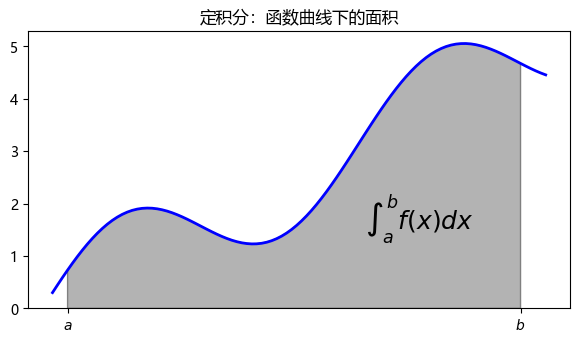

In [10]:
# 积分的几何意义：曲线下面积
from matplotlib.patches import Polygon

xv = np.linspace(0.2, 10, 100)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(xv, f(xv), "b", linewidth=2)
ax.set_ylim(bottom=0)
Ix = np.linspace(a, b)
verts = [(a, 0)] + list(zip(Ix, f(Ix))) + [(b, 0)]
ax.add_patch(Polygon(verts, facecolor="0.7", edgecolor="0.5"))
ax.text(0.75 * (a + b), 1.5, r"$\int_a^b f(x)dx$",
        horizontalalignment="center", fontsize=18)
ax.set_xticks((a, b)); ax.set_xticklabels(("$a$", "$b$"))
ax.set_title("定积分：函数曲线下的面积")

**蒙特卡洛积分**：$\int_a^b f(x)dx = (b-a)\cdot E[f(x)]$，用样本均值逼近期望。
高维问题（多资产衍生品定价）的主力工具。

In [11]:
rng = np.random.default_rng(1000)
N = 500000
x = rng.random(N) * (b - a) + a    # 区间内均匀撒点
np.mean(f(x)) * (b - a)            # 结果 ≈ 24.36，与 quad 基本一致

np.float64(24.363529842327512)

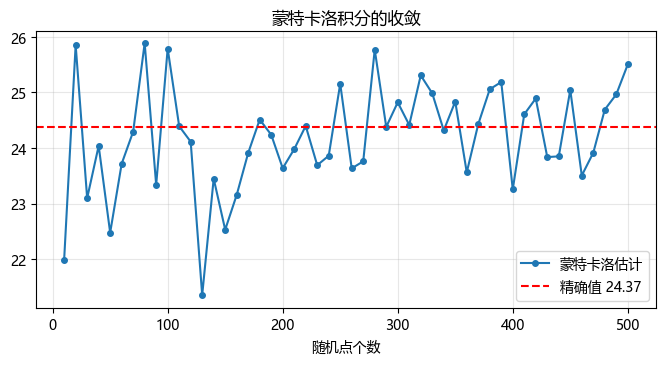

In [12]:
# 观察收敛过程：样本越多越接近精确值（但非单调）
rng = np.random.default_rng(1000)
true_val = sci.quad(f, a, b)[0]
Ns = np.arange(1, 51)
ests = [np.mean(f(rng.random(i * 10) * (b - a) + a)) * (b - a)
        for i in Ns]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(Ns * 10, ests, "o-", markersize=4, label="蒙特卡洛估计")
ax.axhline(true_val, color="red", linestyle="--",
           label=f"精确值 {true_val:.2f}")
ax.set_xlabel("随机点个数")
ax.set_title("蒙特卡洛积分的收敛")
ax.legend()
ax.grid(alpha=0.3)

## 5. 符号计算：SymPy

NumPy 算的是"数"，SymPy 算的是"式子"。

In [13]:
import sympy as sy

x = sy.Symbol("x")        # x 是符号，不是数字
f_sym = sy.sin(x) + 0.5 * x   # 符号表达式
f_sym

0.5*x + sin(x)

In [14]:
sy.solve(x ** 2 - 1, x)   # 解方程：[-1, 1]

[-1, 1]

In [15]:
sy.simplify((x ** 2 - 1) / (x - 1))   # 化简：x + 1

x + 1

In [16]:
sy.diff(f_sym, x)                  # 求导：cos(x) + 0.5

cos(x) + 0.5

In [17]:
sy.integrate(f_sym, x)             # 不定积分：0.25x^2 - cos(x)

0.25*x**2 - cos(x)

In [18]:
sy.integrate(f_sym, (x, 0.5, 9.5)).evalf()   # 定积分：24.3748，与 quad 一致

24.3747547180867

## 6. 课后练习

1. 对 $g(x)=\cos(x)+0.2x$ 分别做 3 次与 9 次多项式回归，比较 MSE 并绘图。
2. 给定期限 [1,2,5,10] 年、利率 [1.6, 1.9, 2.5, 3.1]，
   用三次样条插值估计 3.5 年期利率。
3. 选做：把蒙特卡洛积分的样本数从 1e3 增加到 1e6，记录误差变化，
   验证 1/√N 规律。

<details>
<summary>练习1 参考答案（点击展开）</summary>

```python
def g(x): return np.cos(x) + 0.2 * x

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, g(x), "k", linewidth=2, label="原始函数 g(x)")
for deg in (3, 9):
    reg = np.polyfit(x, g(x), deg)
    mse = np.mean((g(x) - np.polyval(reg, x)) ** 2)
    ax.plot(x, np.polyval(reg, x), label=f"{deg}次 MSE={mse:.6f}")
ax.legend(); ax.grid(alpha=0.3)
```

</details>

<details>
<summary>练习2 参考答案（点击展开）</summary>

```python
ipo3 = spi.splrep([1, 2, 5, 10], [1.6, 1.9, 2.5, 3.1], k=3)
print("3.5年期利率 ≈", round(float(spi.splev(3.5, ipo3)), 3), "%")
```

</details>

<details>
<summary>练习3 参考答案（点击展开）</summary>

```python
rng = np.random.default_rng(42)
exact = sci.quad(f, a, b)[0]
for exp in (3, 4, 5, 6):
    N = 10 ** exp
    est = np.mean(f(rng.random(N) * (b - a) + a)) * (b - a)
    print(f"N=1e{exp}  误差 = {abs(est - exact):.4f}")
# 样本×100，误差大约缩至1/10 —— 即 1/√N 规律
```

</details>